In [43]:
# IMPORTS
# Standard Imports
import os

In [44]:
# Move to repo root
target_folder = "NCEAS_Unsupervised_NLP"
current_dir = os.getcwd()

while os.path.basename(current_dir) != target_folder:
    parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
    if parent_dir == current_dir:
        raise FileNotFoundError(f"{target_folder} not found.")
    current_dir = parent_dir

os.chdir(current_dir)

# Add repo root
sys.path.insert(0, current_dir)

# Add src so custom_packages works
sys.path.insert(0, os.path.join(current_dir, "src"))

In [45]:

# IMPORTS
# Standard Imports
import os
import sys
import re
import warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import phate
import umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, rand_score
from hdbscan import HDBSCAN

from custom_packages.diffusion_condensation import DiffusionCondensation as dc
from custom_packages.fowlkes_mallows import FowlkesMallows

warnings.filterwarnings("ignore")
np.random.seed(42)

# Load arXiv Dataset

In [46]:
import pandas as pd
df = pd.read_csv("src/data/arxiv/data/arxiv/arxiv_30k_clean.csv")
df_new = pd.DataFrame()
df_new["topic"] = df["text"]
df_new["category_1"] = df["label"]
df_new["category_0"] = df["label"].apply(lambda x: x.split(".")[0])

df_new = df_new.dropna().reset_index(drop=True)

In [47]:

df_new = df_new.dropna().reset_index(drop=True)

df_new = df_new[
    df_new["topic"].apply(lambda x: isinstance(x, str) and x.strip() != "")
].reset_index(drop=True)

In [48]:
df_new.to_csv("src/data/arxiv/arxiv_clean.csv", index=False)

In [49]:

df_new.shape

(30000, 3)

# Embedding

In [50]:
dataset_name = "arxiv"
embedding_model = "all-MiniLM-L6-v2"

embed_path = "src/data/arxiv/arxiv_minilm_embeddings.npy"

embedding_list = np.load(embed_path)

print("Embedding shape:", embedding_list.shape)

Embedding shape: (30000, 384)


# Shuffle

In [51]:

embedding_list.shape[0] == len(df_new)
shuffle_idx = np.random.RandomState(seed=42).permutation(len(df_new))
# Shuffle both documents and embeddings using the same index
topic_data = df_new.iloc[shuffle_idx].reset_index(drop=True)
data = np.array(embedding_list)[shuffle_idx] 
reverse_idx = np.argsort(shuffle_idx)
print("Data shape after shuffle:", data.shape)

Data shape after shuffle: (30000, 384)


In [52]:

print(topic_data.columns)

Index(['topic', 'category_1', 'category_0'], dtype='object')


In [53]:
topic_dict = {}
for col in topic_data.columns:
    if re.match(r'^category_\d+$', col): 
        unique_count = len(topic_data[col].unique())
        topic_dict[unique_count] = np.array(topic_data[col])

In [54]:
reducer_model = phate.PHATE(
    n_jobs=-2,
    random_state=42,
    n_components=300,
    decay=20,
    t="auto",
    n_pca=None
)

embed_phate = reducer_model.fit_transform(data)

os.makedirs(f"{embedding_model}_reduced_embeddings", exist_ok=True)

np.save(
    f"{embedding_model}_reduced_embeddings/PHATE_{dataset_name}_embed.npy",
    embed_phate
)

Calculating PHATE...
  Running PHATE on 30000 observations and 384 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 4.12 seconds.
    Calculating affinities...
    Calculated affinities in 5.05 seconds.
  Calculated graph and diffusion operator in 9.34 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 9.12 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.56 seconds.
  Calculated landmark operator in 12.68 seconds.
  Calculating optimal t...
    Automatically selected t = 25
  Calculated optimal t in 2.59 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.74 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 77.47 seconds.
Calculated PHATE in 103.88 seconds.


In [55]:
embedding_methods = {}
embedding_methods["PHATE"] = embed_phate

# Build Hierarchy Levels

In [64]:
depth= 2
cluster_levels=[]
for i in reversed(range(0, depth)):
    cluster_levels.append(len(topic_data[f'category_{i}'].unique()))

In [65]:
import os
print(os.getcwd())
print(os.listdir())

/Users/sukainaalkhalidy/Desktop/CMSE 495 capstone/NCEAS_Unsupervised_NLP
['qwen_embeddings', 'LICENSE', 'requirements.txt', 'Untitled.ipynb', 'Qwen3-Embedding-0.6B_reduced_embeddings', 'all-MiniLM-L6-v2_results', 'all-MiniLM-L6-v2_reduced_embeddings', 'docs', 'qwen_reduced_embeddings', 'text-embedding-3-large_results', 'README.md', 'Qwen3-Embedding-0.6B_results', '.gitignore', '.git', 'gpt_embeddings', 'src']


In [66]:
base_path = "all-MiniLM-L6-v2_reduced_embeddings"
embedding_methods = {}

embedding_methods["PHATE"] = np.load(
    f"{base_path}/PHATE_{dataset_name}_embed.npy"
)

embedding_methods["PCA"] = np.load(
    f"{base_path}/PCA_{dataset_name}_embed.npy"
)

embedding_methods["UMAP"] = np.load(
    f"{base_path}/UMAP_{dataset_name}_embed.npy"
)

# I run this in HPCC

# ============================================================
# arxiv_minilm_benchmark.py
# HPCC-ready (flat directory version)
# ============================================================

import os
import numpy as np
import pandas as pd
import umap
import phate

from collections import defaultdict
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, rand_score
from scipy.cluster.hierarchy import fcluster
from hdbscan import HDBSCAN

# ------------------------------------------------------------
# Local imports (files must be in SAME directory)
# ------------------------------------------------------------
from diffusion_condensation import DiffusionCondensation as dc
from fowlkes_mallows import FowlkesMallows

# ============================================================
# Configuration
# ============================================================

dataset_name = "arxiv"
embedding_model = "all-MiniLM-L6-v2"

data_path = "arxiv_30k_clean.csv"
embedding_path = "arxiv_minilm_embeddings.npy"

# ============================================================
# Safety Checks
# ============================================================

if not os.path.exists(data_path):
    raise FileNotFoundError(f"{data_path} not found")

if not os.path.exists(embedding_path):
    raise FileNotFoundError(f"{embedding_path} not found")

# ============================================================
# Create output folders
# ============================================================

os.makedirs(f"{embedding_model}_reduced_embeddings", exist_ok=True)
os.makedirs(f"{embedding_model}_results", exist_ok=True)

# ============================================================
# Load dataset
# ============================================================

print("Loading dataset...")
df = pd.read_csv(data_path)

df_new = pd.DataFrame()
df_new["topic"] = df["text"]
df_new["category_1"] = df["label"]
df_new["category_0"] = df["label"].apply(lambda x: x.split(".")[0])

df_new = df_new.dropna().reset_index(drop=True)

print("Dataset shape:", df_new.shape)

# ============================================================
# Load embeddings
# ============================================================

print("Loading embeddings...")
embedding_list = np.load(embedding_path)

print("Embedding shape:", embedding_list.shape)

if len(df_new) != len(embedding_list):
    raise ValueError("Mismatch between dataset and embeddings length")

# ============================================================
# Shuffle consistently
# ============================================================

print("Shuffling data...")
shuffle_idx = np.random.RandomState(seed=42).permutation(len(df_new))

topic_data = df_new.iloc[shuffle_idx].reset_index(drop=True)
data = embedding_list[shuffle_idx]

# ============================================================
# Build topic dictionary
# ============================================================

topic_dict = {}
for col in topic_data.columns:
    if col.startswith("category_"):
        unique_count = len(topic_data[col].unique())
        topic_dict[unique_count] = np.array(topic_data[col])

# ============================================================
# Cluster levels
# ============================================================

depth = 2
cluster_levels = [
    len(topic_data[f"category_{i}"].unique())
    for i in reversed(range(depth))
]

print("Cluster levels:", cluster_levels)

# ============================================================
# Dimensionality Reduction
# ============================================================

embeddings = np.array(data)
embedding_methods = {}

# ---------------- PHATE ----------------
print("\nRunning PHATE...")
phate_model = phate.PHATE(
    n_jobs=-1,
    random_state=42,
    n_components=50
)

embed_phate = phate_model.fit_transform(embeddings)
embedding_methods["PHATE"] = embed_phate

np.save(
    f"{embedding_model}_reduced_embeddings/PHATE_{dataset_name}_embed.npy",
    embed_phate
)

# ---------------- PCA ----------------
print("Running PCA...")
pca = PCA(n_components=50, random_state=42)
embed_pca = pca.fit_transform(embeddings)
embedding_methods["PCA"] = embed_pca

np.save(
    f"{embedding_model}_reduced_embeddings/PCA_{dataset_name}_embed.npy",
    embed_pca
)

# ---------------- UMAP ----------------
print("Running UMAP...")
umap_model = umap.UMAP(
    n_components=50,
    random_state=42,
    min_dist=0.05,
    n_neighbors=10
)

embed_umap = umap_model.fit_transform(embeddings)
embedding_methods["UMAP"] = embed_umap

np.save(
    f"{embedding_model}_reduced_embeddings/UMAP_{dataset_name}_embed.npy",
    embed_umap
)

# ============================================================
# Clustering + Metrics
# ============================================================

print("\nRunning clustering...")

scores_all = defaultdict(lambda: defaultdict(list))

for embed_name, embed_data in tqdm(embedding_methods.items()):

    print(f"\nProcessing {embed_name}")

    for cluster_method in ["Agglomerative", "HDBSCAN", "DC"]:

        print(f"  {cluster_method}")

        for level in cluster_levels:

            # ---------------- Clustering ----------------
            if cluster_method == "Agglomerative":
                model = AgglomerativeClustering(n_clusters=level)
                labels = model.fit_predict(embed_data)

            elif cluster_method == "HDBSCAN":
                model = HDBSCAN(min_cluster_size=level)
                model.fit(embed_data)
                Z = model.single_linkage_tree_.to_numpy()
                labels = fcluster(Z, level, criterion="maxclust")
                labels[labels == -1] = labels.max() + 1

            elif cluster_method == "DC":
                model = dc(min_clusters=level, max_iterations=5000)
                model.fit(embed_data)
                labels = model.labels_

            # ---------------- Align labels safely ----------------
            available_levels = np.array(sorted(topic_dict.keys()))
            closest_level = min(available_levels, key=lambda k: abs(k - level))

            target = topic_dict[closest_level]

            valid_idx = ~pd.isna(target)
            target = target[valid_idx]
            labels = labels[valid_idx]

            # ---------------- Metrics ----------------
            try:
                fm_score = FowlkesMallows.Bk(
                    {level: target},
                    {level: labels}
                )[level]["FM"]
            except Exception:
                fm_score = np.nan

            scores_all[(embed_name, cluster_method)]["FM"].append(fm_score)
            scores_all[(embed_name, cluster_method)]["Rand"].append(
                rand_score(target, labels)
            )
            scores_all[(embed_name, cluster_method)]["ARI"].append(
                adjusted_rand_score(target, labels)
            )

# ============================================================
# Save Results
# ============================================================

print("\nSaving results...")

rows = []

for (embed_name, cluster_method), score_dict in scores_all.items():
    for i, level in enumerate(cluster_levels):
        rows.append({
            "reduction_method": embed_name,
            "cluster_method": cluster_method,
            "level": level,
            "FM": score_dict["FM"][i],
            "Rand": score_dict["Rand"][i],
            "ARI": score_dict["ARI"][i],
        })

scores_df = pd.DataFrame(rows)

output_path = f"{embedding_model}_results/other_{dataset_name}_results.csv"

scores_df.to_csv(output_path, index=False)

print("\n====================================")
print("MiniLM Benchmark complete.")
print("Results saved to:", output_path)
print("====================================")

# Hierarchical Clustering Benchmark Results

In [68]:
import os
print(os.getcwd())

/Users/sukainaalkhalidy/Desktop/CMSE 495 capstone/NCEAS_Unsupervised_NLP


  reduction_method cluster_method  level        FM      Rand       ARI
0            PHATE  Agglomerative     62  0.240213  0.934574  0.184611
1            PHATE  Agglomerative      2  0.941324  0.921053  0.821506
2            PHATE        HDBSCAN     62  0.296351  0.377063  0.056801
3            PHATE        HDBSCAN      2  0.810250  0.656527 -0.000048
4            PHATE             DC     62  0.233105  0.929782  0.185069


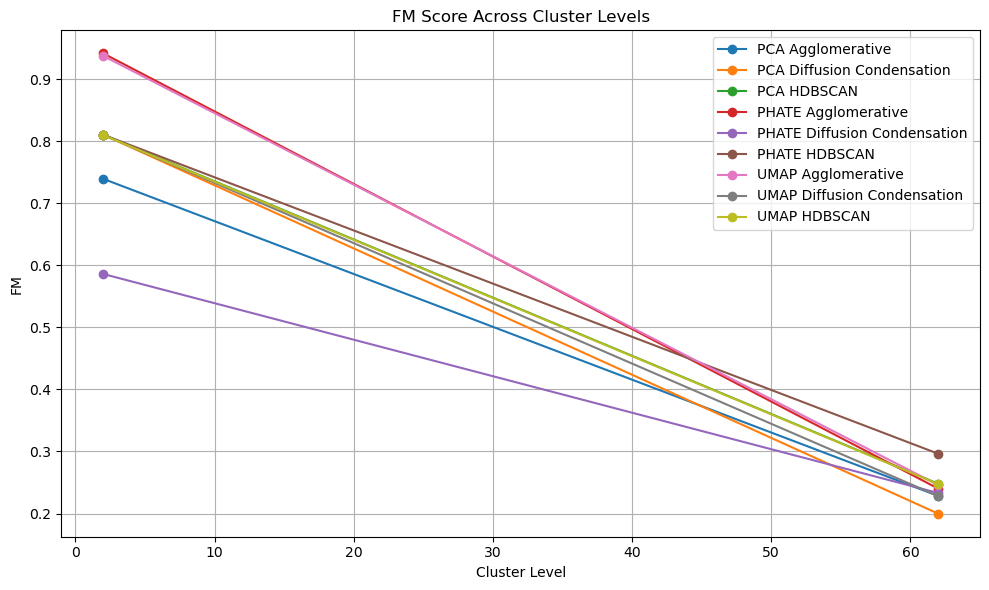

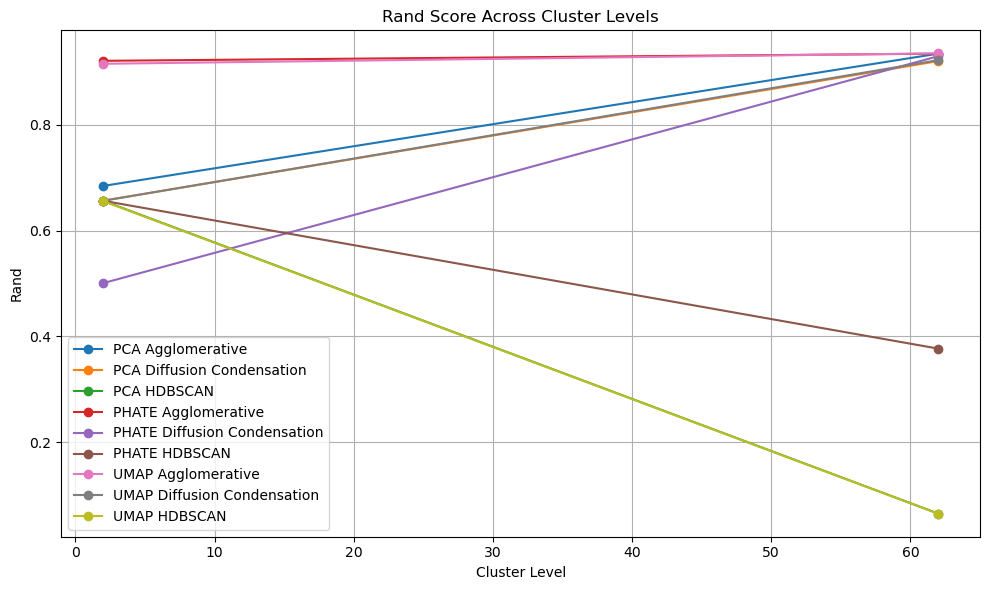

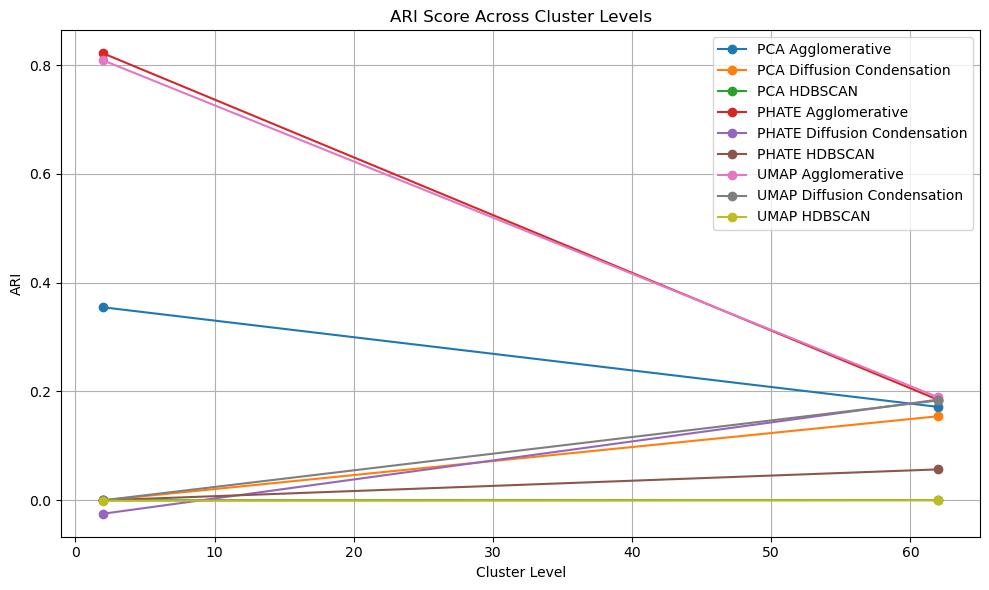

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
scores_df = pd.read_csv(
    "all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv"
)
print(scores_df.head())

metrics = ["FM", "Rand", "ARI"]

for metric in metrics:
    plt.figure(figsize=(10, 6))

    for (reduction, method), group in scores_df.groupby(
        ["reduction_method", "cluster_method"]
    ):
        if method == "DC":
            method = "Diffusion Condensation"

        plt.plot(
            group["level"],
            group[metric],
            marker='o',
            label=f"{reduction} {method}"
        )

    plt.title(f"{metric} Score Across Cluster Levels")
    plt.xlabel("Cluster Level")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()